In [1]:
# Load Dataset
import kagglehub
import pandas as pd
import numpy as np

path = kagglehub.dataset_download("faviovaz/marketing-ab-testing")

print("Dataset path:", path)

100%|██████████| 5.23M/5.23M [00:00<00:00, 160MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/faviovaz/marketing-ab-testing/versions/1


In [2]:
# Load CSV File
import os

print(os.listdir(path))
df = pd.read_csv(os.path.join(path, "marketing_AB.csv"))

df.head()

['marketing_AB.csv']


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [4]:
# Understand Dataset
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


Index(['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads',
       'most ads day', 'most ads hour'],
      dtype='object')

In [6]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [7]:
control = df[df["test_group"] == "ad"]
treatment = df[df["test_group"] == "psa"]

print("Control size:", len(control))
print("Treatment size:", len(treatment))

Control size: 564577
Treatment size: 23524


In [8]:
# Conversion Rate Analysis
control_conv_rate = control["converted"].mean()
treatment_conv_rate = treatment["converted"].mean()

print("Control Conversion Rate:", control_conv_rate)
print("Treatment Conversion Rate:", treatment_conv_rate)

Control Conversion Rate: 0.025546559636683747
Treatment Conversion Rate: 0.01785410644448223


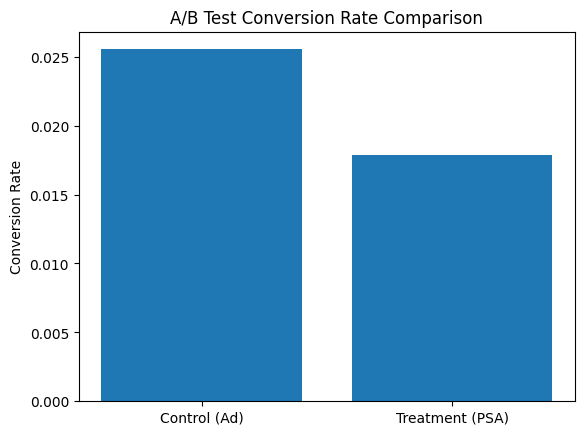

In [9]:
# Visual Comparison
import matplotlib.pyplot as plt

plt.bar(
    ["Control (Ad)", "Treatment (PSA)"],
    [control_conv_rate, treatment_conv_rate]
)

plt.title("A/B Test Conversion Rate Comparison")
plt.ylabel("Conversion Rate")
plt.show()

In [10]:
# Statistical Significance Test
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

success = np.array([
    control["converted"].sum(),
    treatment["converted"].sum()
])

nobs = np.array([
    len(control),
    len(treatment)
])

z_stat, p_value = proportions_ztest(success, nobs)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 7.3700781265454145
P-value: 1.7052807161559727e-13


In [11]:
# Decision Rule
alpha = 0.05

if p_value < alpha:
    print("✅ Reject H0 → Significant difference exists")
else:
    print("❌ Fail to reject H0 → No significant difference")

✅ Reject H0 → Significant difference exists


In [12]:
# Business Impact (Revenue/Effect Insight)
control_conversions = control["converted"].sum()
treatment_conversions = treatment["converted"].sum()

print("Control Conversions:", control_conversions)
print("Treatment Conversions:", treatment_conversions)

print("Lift in conversions:", treatment_conversions - control_conversions)

Control Conversions: 14423
Treatment Conversions: 420
Lift in conversions: -14003
